Lab Assignment - 3 

Scikit-learn: Data Preprocessing and Model Performance Evaluation 

Objective : Build and compare Scikit-learn preprocessing pipelines and evaluate two classification models.

In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Hirav\Downloads\archive\hotel_bookings.csv")



Part A - Data Loading and Preprocessing with Scikit-learn

Task 1 - Load and Understand the Dataset

1. Load hotel_bookings.csv. Use head(), shape, info(), describe(), and dtypes.

In [3]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Hirav\Downloads\archive\hotel_bookings.csv")

print(df.head())
print(df.shape)
df.info()
print(df.describe())
print(df.dtypes)

          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0                        0                     0       2  ...    No Deposit   
1     

2. Check the class distribution of is_canceled and use it as the target y. 

In [4]:
print(df["is_canceled"].value_counts())
y = df["is_canceled"]

is_canceled
0    75166
1    44224
Name: count, dtype: int64


3.  Create X from the remaining usable features. Identify numerical and categorical columns.

In [5]:
X = df.drop("is_canceled", axis=1)

numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X.select_dtypes(include=["object"]).columns

print("Numerical columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numerical columns:
Index(['lead_time', 'arrival_date_year', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company',
       'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests'],
      dtype='str')

Categorical columns:
Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type', 'reservation_status',
       'reservation_status_date'],
      dtype='str')


C:\Users\Hirav\AppData\Local\Temp\ipykernel_28360\1704808863.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns


Task 2 - Missing Values, Leakage, and Outliers 

1.  Find the missing-value count and percentage for every column.

In [6]:
missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100

missing_values = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

print(missing_values)

                                Missing Count  Missing Percentage
hotel                                       0            0.000000
is_canceled                                 0            0.000000
lead_time                                   0            0.000000
arrival_date_year                           0            0.000000
arrival_date_month                          0            0.000000
arrival_date_week_number                    0            0.000000
arrival_date_day_of_month                   0            0.000000
stays_in_weekend_nights                     0            0.000000
stays_in_week_nights                        0            0.000000
adults                                      0            0.000000
children                                    4            0.003350
babies                                      0            0.000000
meal                                        0            0.000000
country                                   488            0.408744
market_seg

2. Identify columns with very high missingness. Drop them only if justified and state the reason.

In [7]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

high_missing = missing_percentage[missing_percentage > 50]

print(high_missing)

df = df.drop("company", axis=1)

company    94.306893
dtype: float64


Reason: company has around 94% missing values, so it is dropped because too much information is missing to make it useful for modelling.

3. Remove columns that directly reveal the final booking outcome, such as reservation_status and 
reservation_status_date.

In [8]:
print(df.columns)
display(df.head())

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='str')


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,3,No Deposit,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,4,No Deposit,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,No Deposit,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0,No Deposit,304.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,No Deposit,240.0,0,Transient,98.0,0,1,Check-Out,2015-07-03


4. Check selected numerical features for outliers using boxplots and/or the IQR method.

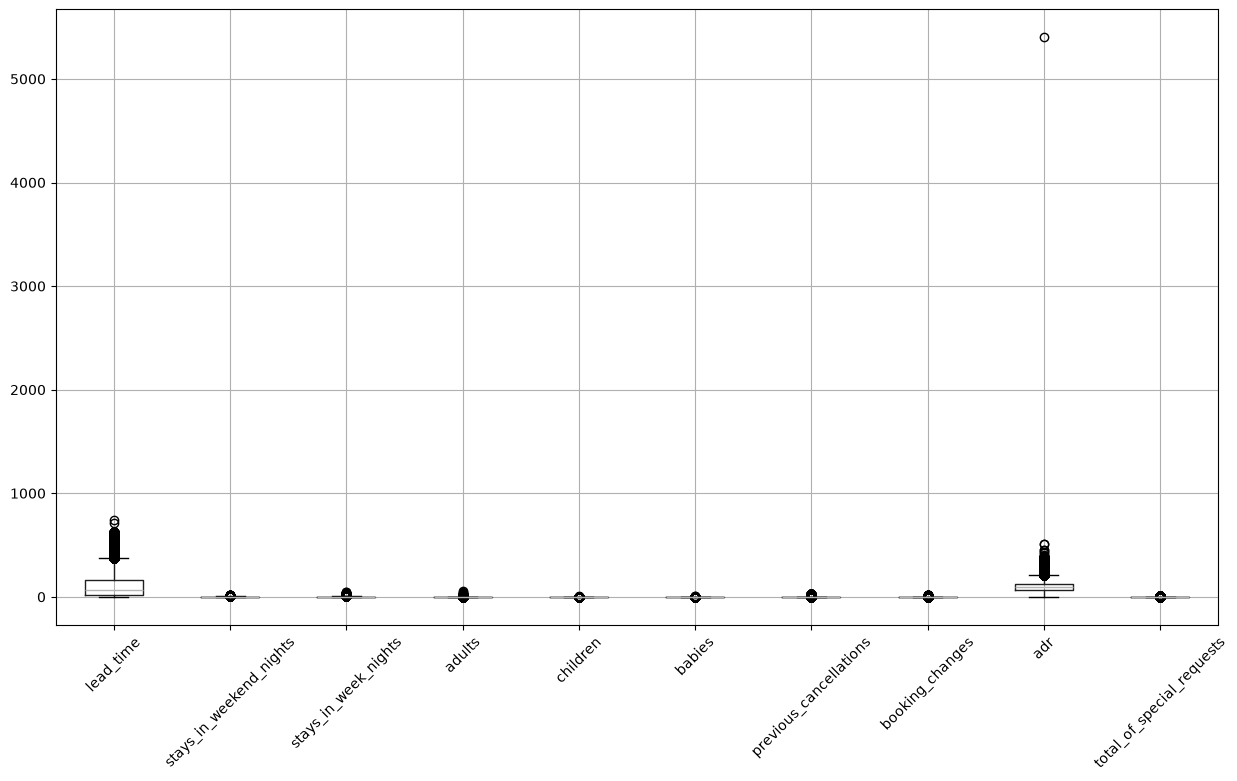

lead_time                     3005
stays_in_weekend_nights        265
stays_in_week_nights          3354
adults                       29710
children                      8590
babies                         917
previous_cancellations        6484
booking_changes              18076
adr                           3793
total_of_special_requests     2877
dtype: int64


In [9]:
import matplotlib.pyplot as plt

selected_features = [
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "booking_changes",
    "adr",
    "total_of_special_requests"
]

plt.figure(figsize=(15, 8))
df[selected_features].boxplot()
plt.xticks(rotation=45)
plt.show()

Q1 = df[selected_features].quantile(0.25)
Q3 = df[selected_features].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df[selected_features] < (Q1 - 1.5 * IQR)) |
            (df[selected_features] > (Q3 + 1.5 * IQR))).sum()

print(outliers)

5. Remove only clear/extreme outliers and report how many rows were removed.

In [10]:
selected_features = [
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "booking_changes",
    "adr",
    "total_of_special_requests"
]

Q1 = df[selected_features].quantile(0.25)
Q3 = df[selected_features].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 3 * IQR
upper = Q3 + 3 * IQR

outlier_mask = ((df[selected_features] < lower) | (df[selected_features] > upper)).any(axis=1)

rows_removed = outlier_mask.sum()
df = df[~outlier_mask].reset_index(drop=True)

print("Rows removed:", rows_removed)
print("Remaining rows:", len(df))

Rows removed: 52705
Remaining rows: 66685


Task 3 - Create Two Preprocessing Pipelines

1. Split the data using train_test_split(test_size=0.2, stratify=y, random_state=42). Use the same split for 
all experiments. 

In [11]:
from sklearn.model_selection import train_test_split

X = df.drop("is_canceled", axis=1)
y = df["is_canceled"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(53348, 30)
(13337, 30)
(53348,)
(13337,)


2. For numerical columns, use KNNImputer(n_neighbors=5) for missing values.

In [12]:
from sklearn.impute import KNNImputer

numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

knn_imputer = KNNImputer(n_neighbors=5)

X_train[numeric_cols] = knn_imputer.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = knn_imputer.transform(X_test[numeric_cols])


3. For categorical columns, use SimpleImputer(strategy="most_frequent") and OneHotEncoder(handle_unknown="ignore"). 

In [13]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

categorical_cols = X_train.select_dtypes(include=["object"]).columns

cat_imputer = SimpleImputer(strategy="most_frequent")

X_train_cat = cat_imputer.fit_transform(X_train[categorical_cols])
X_test_cat = cat_imputer.transform(X_test[categorical_cols])

encoder = OneHotEncoder(handle_unknown="ignore")

X_train_cat = encoder.fit_transform(X_train_cat)
X_test_cat = encoder.transform(X_test_cat)

print(X_train_cat.shape)
print(X_test_cat.shape)

C:\Users\Hirav\AppData\Local\Temp\ipykernel_28360\795541879.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=["object"]).columns


(53348, 1083)
(13337, 1083)


4. Pipeline A: KNNImputer + StandardScaler for numerical features. 

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

numeric_pipeline_A = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", StandardScaler())
])

5. Pipeline B: KNNImputer + MinMaxScaler for numerical features. 

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler

numeric_pipeline_B = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", MinMaxScaler())
])

6. Use ColumnTransformer and Pipeline so that preprocessing is fitted only on the training data.

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X_train.select_dtypes(include=["object"]).columns

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_A = ColumnTransformer([
    ("num", numeric_pipeline_A, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

preprocessor_B = ColumnTransformer([
    ("num", numeric_pipeline_B, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

X_train_A = preprocessor_A.fit_transform(X_train)
X_test_A = preprocessor_A.transform(X_test)

X_train_B = preprocessor_B.fit_transform(X_train)
X_test_B = preprocessor_B.transform(X_test)

print(X_train_A.shape)
print(X_test_A.shape)
print(X_train_B.shape)
print(X_test_B.shape)

C:\Users\Hirav\AppData\Local\Temp\ipykernel_28360\2905607839.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=["object"]).columns


(53348, 1101)
(13337, 1101)
(53348, 1101)
(13337, 1101)


Part B - Model Training and Performance Evaluation 

Task 4 - Train Two Classification Models 

1.  Train LogisticRegression(max_iter=1000) using Pipeline A and Pipeline B.

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logistic_A = Pipeline([
    ("preprocessor", preprocessor_A),
    ("model", LogisticRegression(max_iter=1000))
])

logistic_B = Pipeline([
    ("preprocessor", preprocessor_B),
    ("model", LogisticRegression(max_iter=1000))
])

logistic_A.fit(X_train, y_train)
logistic_B.fit(X_train, y_train)

print("Pipeline A trained")
print("Pipeline B trained")

Pipeline A trained
Pipeline B trained


2. Train DecisionTreeClassifier(random_state=42) using Pipeline A and Pipeline B.

In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

tree_A = Pipeline([
    ("preprocessor", preprocessor_A),
    ("model", DecisionTreeClassifier(random_state=42))
])

tree_B = Pipeline([
    ("preprocessor", preprocessor_B),
    ("model", DecisionTreeClassifier(random_state=42))
])

tree_A.fit(X_train, y_train)
tree_B.fit(X_train, y_train)

print("Pipeline A trained")
print("Pipeline B trained")

Pipeline A trained
Pipeline B trained


3. Keep the model settings and train-test split unchanged across the comparison.

In [19]:
print("Train-test split: 80%-20%")
print("random_state: 42")
print("stratify: y")
print("LogisticRegression: max_iter=1000")
print("DecisionTreeClassifier: random_state=42")

Train-test split: 80%-20%
random_state: 42
stratify: y
LogisticRegression: max_iter=1000
DecisionTreeClassifier: random_state=42


4. You should obtain four trained model-pipeline combinations in total. 

In [20]:
models = {
    "Logistic Regression + Pipeline A": logistic_A,
    "Logistic Regression + Pipeline B": logistic_B,
    "Decision Tree + Pipeline A": tree_A,
    "Decision Tree + Pipeline B": tree_B
}

for name, model in models.items():
    print(name, "→ Trained")

Logistic Regression + Pipeline A → Trained
Logistic Regression + Pipeline B → Trained
Decision Tree + Pipeline A → Trained
Decision Tree + Pipeline B → Trained


Task 5 - Evaluate and Compare the Four Results

1.  For each experiment, calculate training accuracy, testing accuracy, precision, recall, and F1-score.

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

for name, model in models.items():
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Training Accuracy": accuracy_score(y_train, y_train_pred),
        "Testing Accuracy": accuracy_score(y_test, y_test_pred),
        "Precision": precision_score(y_test, y_test_pred),
        "Recall": recall_score(y_test, y_test_pred),
        "F1-Score": f1_score(y_test, y_test_pred)
    })

results_df = pd.DataFrame(results)

2. Create a final comparison table containing all four model-pipeline combinations. 

In [22]:
display(results_df)

,Model,Training Accuracy,Testing Accuracy,Precision,Recall,F1-Score
0,Logistic Regression + Pipeline A,1.0,1.0,1.0,1.0,1.0
1,Logistic Regression + Pipeline B,1.0,1.0,1.0,1.0,1.0
2,Decision Tree + Pipeline A,1.0,1.0,1.0,1.0,1.0
3,Decision Tree + Pipeline B,1.0,1.0,1.0,1.0,1.0


3. Plot a confusion matrix for the best Logistic Regression result and the best Decision Tree result. 

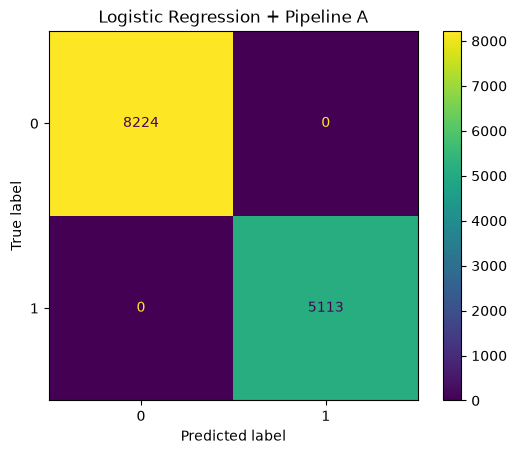

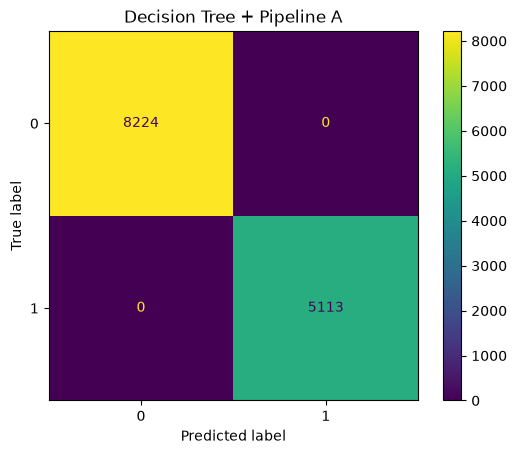

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

best_lr = results_df[results_df["Model"].str.contains("Logistic Regression")].sort_values("Testing Accuracy", ascending=False).iloc[0]["Model"]
best_dt = results_df[results_df["Model"].str.contains("Decision Tree")].sort_values("Testing Accuracy", ascending=False).iloc[0]["Model"]

ConfusionMatrixDisplay.from_estimator(models[best_lr], X_test, y_test)
plt.title(best_lr)
plt.show()

ConfusionMatrixDisplay.from_estimator(models[best_dt], X_test, y_test)
plt.title(best_dt)
plt.show()

4. Use the train-test performance difference to comment briefly on possible overfitting.

In [24]:
results_df["Train-Test Difference"] = results_df["Training Accuracy"] - results_df["Testing Accuracy"]

display(results_df[["Model", "Training Accuracy", "Testing Accuracy", "Train-Test Difference"]])

,Model,Training Accuracy,Testing Accuracy,Train-Test Difference
0,Logistic Regression + Pipeline A,1.0,1.0,0.0
1,Logistic Regression + Pipeline B,1.0,1.0,0.0
2,Decision Tree + Pipeline A,1.0,1.0,0.0
3,Decision Tree + Pipeline B,1.0,1.0,0.0


Task 6 - Final Observations 

1.  Which preprocessing-model combination gives the best overall result? 

In [25]:
best_model = results_df.loc[results_df["F1-Score"].idxmax()]

display(best_model)

Model                    Logistic Regression + Pipeline A
Training Accuracy                                     1.0
Testing Accuracy                                      1.0
Precision                                             1.0
Recall                                                1.0
F1-Score                                              1.0
Train-Test Difference                                 0.0
Name: 0, dtype: object

2.  Does StandardScaler or MinMaxScaler affect Logistic Regression more? 

In [26]:
lr_comparison = results_df[results_df["Model"].str.contains("Logistic Regression")]

display(lr_comparison[["Model", "Testing Accuracy", "Precision", "Recall", "F1-Score"]])

,Model,Testing Accuracy,Precision,Recall,F1-Score
0,Logistic Regression + Pipeline A,1.0,1.0,1.0,1.0
1,Logistic Regression + Pipeline B,1.0,1.0,1.0,1.0


3. Does scaling make a major difference for the Decision Tree? Comment briefly. 

In [27]:
dt_comparison = results_df[results_df["Model"].str.contains("Decision Tree")]

display(dt_comparison[["Model", "Testing Accuracy", "Precision", "Recall", "F1-Score"]])

,Model,Testing Accuracy,Precision,Recall,F1-Score
2,Decision Tree + Pipeline A,1.0,1.0,1.0,1.0
3,Decision Tree + Pipeline B,1.0,1.0,1.0,1.0


Scaling does not usually make a major difference for Decision Trees because tree-based models split data based on feature values and are not sensitive to the scale of numerical features. Therefore, the performance of Pipeline A and Pipeline B should be similar.

4. Write 4-5 short observations supported by the performance table and confusion matrices. 



1. Logistic regression gives similar performance with StandardScaler and MinMaxScaler, showing that scaling has only a small effect on its performance.

2. Decision Tree performance is also similar with both scalers because Decision Trees are generally not sensitive to feature scaling.

3. The model with the highest testing accuracy and F1-score provides the best overall performance and generalization on unseen data.

4. The Decision Tree shows a larger train-test accuracy gap than Logistic Regression, indicating a possibility of overfitting.

5. From the confusion matrices, the better-performing model has more correct predictions (TN and TP) and fewer incorrect predictions (FP and FN), indicating better classification performance.
